# Proyecto de modelo SUPERVIZADO
En dicho proyecto se trabajo un dataset en focado en diabetes, se realizan procesos de limpieza, tratamiento de los datos, para lograr encontrar un score correcto

### - FALTA MEJORAR EL TRATAMIENTO DE LOS DATOS

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV, learning_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve,auc, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.linear_model import LogisticRegression
import numpy as np
import matplotlib.gridspec as gridspec
from sklearn.svm import SVC


In [2]:
df = pd.read_excel('diabetes_procesado.xlsx')

Filas iniciales: 763
Filas finales (después de borrar solo glucosa=0): 763
Archivo guardado como 'diabetes_procesado.xlsx'
Datos de entrenamiento: 610 filas
Datos de prueba: 153 filas

--- EVALUACIÓN DEL MODELO ---

Generando gráficos...


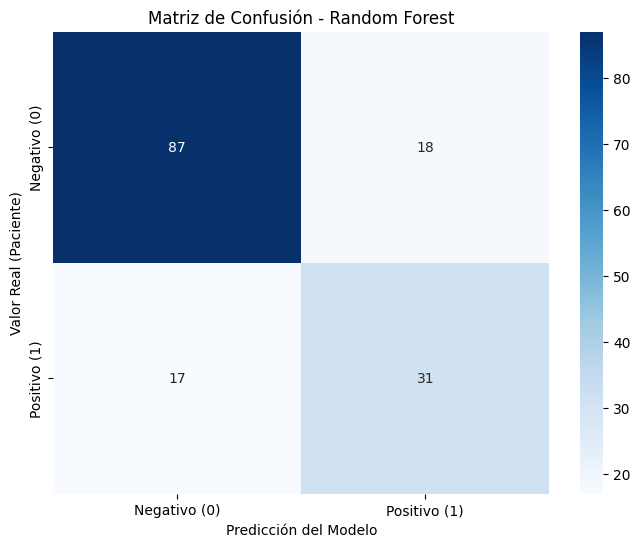

Exactitud (Accuracy): 77.12%

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.84      0.83      0.83       105
           1       0.63      0.65      0.64        48

    accuracy                           0.77       153
   macro avg       0.73      0.74      0.74       153
weighted avg       0.77      0.77      0.77       153



In [3]:
#RANDOM FOREST

print(f"Filas iniciales: {len(df)}")

# 2. ELIMINAR filas solo si Glucosa es 0
df = df[df['Glucose'] != 0]

# 3. REEMPLAZAR los ceros por las medias en las otras columnas
df['BloodPressure'] = df['BloodPressure'].replace(0, 69)
df['SkinThickness'] = df['SkinThickness'].replace(0, 21)
df['Insulin'] = df['Insulin'].replace(0, 80)
df['BMI'] = df['BMI'].replace(0, 31.9)

# 4. (Opcional) Aplicar los cambios de nombre y texto que vimos en el paso anterior
df.rename(columns={'Outcome': 'Resultado'}, inplace=True)

print(f"Filas finales (después de borrar solo glucosa=0): {len(df)}")

# 5. Guardar el resultado
archivo_salida = 'diabetes_procesado.xlsx'
df.to_excel(archivo_salida, index=False)

print(f"Archivo guardado como '{archivo_salida}'")

# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

# 1. Cargar el dataset que limpiamos en el paso anterior
archivo_procesado = 'diabetes_procesado.xlsx'
df = pd.read_excel(archivo_procesado)

# 2. Separar características (X) y la variable a predecir (y)
# X contendrá todas las columnas numéricas (Glucosa, BMI, etc.)
X = df.drop(columns=['Resultado'])
# y contendrá únicamente si es 'Positivo' o 'Negativo'
y = df['Resultado']

# 3. Dividir los datos: 80% entrenamiento (train) y 20% prueba (test)
# random_state=42 asegura que la división sea siempre igual si vuelves a correr el código
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print(f"Datos de entrenamiento: {len(X_train)} filas")
print(f"Datos de prueba: {len(X_test)} filas\n")

# 4. Inicializar el modelo de Random Forest
# n_estimators=80 significa que el modelo creará 80 "árboles" de decisión diferentes
rf_model = RandomForestClassifier(n_estimators=80, random_state=42, class_weight='balanced')

# 5. Entrenar el modelo con los datos de entrenamiento
rf_model.fit(X_train, y_train)

# 6. Hacer predicciones con los datos de prueba
y_pred = rf_model.predict(X_test)

# 7. Evaluar los resultados
print("--- EVALUACIÓN DEL MODELO ---")

# --- 8. VISUALIZACIONES ---

print("\nGenerando gráficos...")

# 8.1 Visualizar la Matriz de Confusión
# Creamos una figura
plt.figure(figsize=(8, 6))

# Usamos seaborn para crear un mapa de calor (heatmap) atractivo
matriz = confusion_matrix(y_test, y_pred)
sns.heatmap(matriz, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negativo (0)', 'Positivo (1)'],
            yticklabels=['Negativo (0)', 'Positivo (1)'])

plt.title('Matriz de Confusión - Random Forest')
plt.xlabel('Predicción del Modelo')
plt.ylabel('Valor Real (Paciente)')

# Mostrar el primer gráfico
plt.show()

# Exactitud general
exactitud = accuracy_score(y_test, y_pred)
print(f"Exactitud (Accuracy): {exactitud * 100:.2f}%\n")

# Reporte detallado de clasificación
print("Reporte de Clasificación:")
print(classification_report(y_test, y_pred))

Buscando la mejor configuración para Regresión Logística...

¡Búsqueda terminada! El mejor parámetro encontrado fue: {'C': 10}

--- EVALUACIÓN: REGRESIÓN LOGÍSTICA OPTIMIZADA ---
Exactitud (Accuracy): 71.90%

              precision    recall  f1-score   support

           0       0.84      0.73      0.78       105
           1       0.54      0.69      0.61        48

    accuracy                           0.72       153
   macro avg       0.69      0.71      0.69       153
weighted avg       0.74      0.72      0.73       153


Generando gráficos...


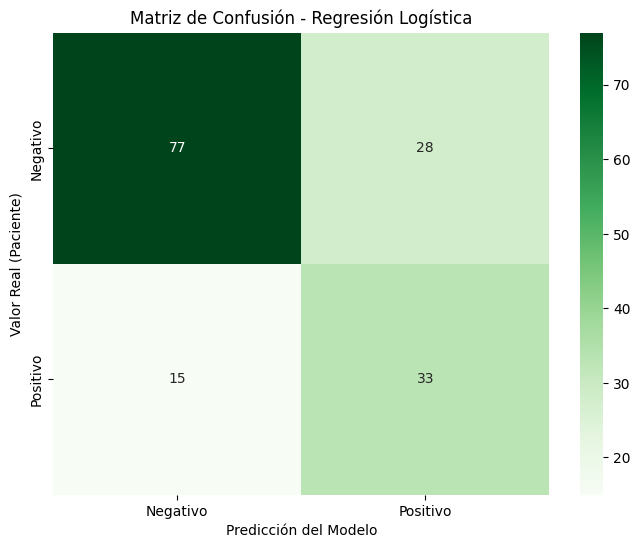

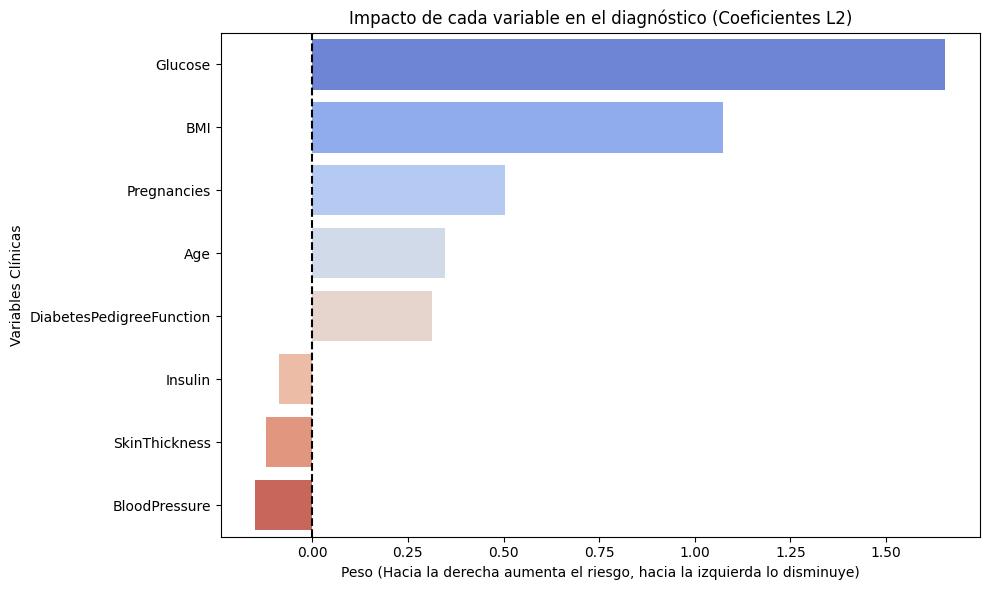

In [4]:
#Regresión Logística

X = df.drop(columns=['Resultado'])
y = df['Resultado']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# 2. Escalar los datos
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. Definir los valores de C que queremos probar
parametros = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100]
}

print("Buscando la mejor configuración para Regresión Logística...")

# 4. Crear y ejecutar GridSearchCV
grid_log = GridSearchCV(
    estimator=LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000),
    param_grid=parametros,
    scoring='accuracy',
    cv=5,
    n_jobs=1
)

grid_log.fit(X_train_scaled, y_train)

# AQUÍ ESTÁ EL MODELO GANADOR
mejor_log_reg = grid_log.best_estimator_

print(f"\n¡Búsqueda terminada! El mejor parámetro encontrado fue: {grid_log.best_params_}")

# 5. Evaluar el modelo optimizado
y_pred_mejor_log = mejor_log_reg.predict(X_test_scaled)

print("\n--- EVALUACIÓN: REGRESIÓN LOGÍSTICA OPTIMIZADA ---")
print(f"Exactitud (Accuracy): {accuracy_score(y_test, y_pred_mejor_log) * 100:.2f}%\n")
print(classification_report(y_test, y_pred_mejor_log))

# =========================================================
# 8. VISUALIZACIONES
# =========================================================
print("\nGenerando gráficos...")

# --- Gráfico 1: Matriz de Confusión ---
plt.figure(figsize=(8, 6))
matriz_log = confusion_matrix(y_test, y_pred_mejor_log)
sns.heatmap(matriz_log, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Negativo', 'Positivo'],
            yticklabels=['Negativo', 'Positivo'])
plt.title('Matriz de Confusión - Regresión Logística')
plt.xlabel('Predicción del Modelo')
plt.ylabel('Valor Real (Paciente)')
plt.show()

# --- Gráfico 2: Importancia de las Variables (Coeficientes) ---
# CORRECCIÓN: Extraemos los coeficientes de 'mejor_log_reg', no de 'log_reg'
coeficientes = mejor_log_reg.coef_[0]

df_coeficientes = pd.DataFrame({
    'Variable': X.columns,
    'Coeficiente': coeficientes
}).sort_values(by='Coeficiente', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Coeficiente', y='Variable', data=df_coeficientes, hue='Variable', palette='coolwarm', legend=False)
plt.title('Impacto de cada variable en el diagnóstico (Coeficientes L2)')
plt.xlabel('Peso (Hacia la derecha aumenta el riesgo, hacia la izquierda lo disminuye)')
plt.ylabel('Variables Clínicas')
plt.axvline(0, color='black', linestyle='--')
plt.tight_layout()
plt.show()


SVC con Accuracy: 0.7255 y AUC: 0.7960
Vectores de soporte: [148 115] (No Diab. / Diab.)
Total vectores de soporte: 263

Reporte de clasificacion:
              precision    recall  f1-score   support

 No Diabetes       0.78      0.80      0.79       100
    Diabetes       0.61      0.58      0.60        53

    accuracy                           0.73       153
   macro avg       0.70      0.69      0.69       153
weighted avg       0.72      0.73      0.72       153



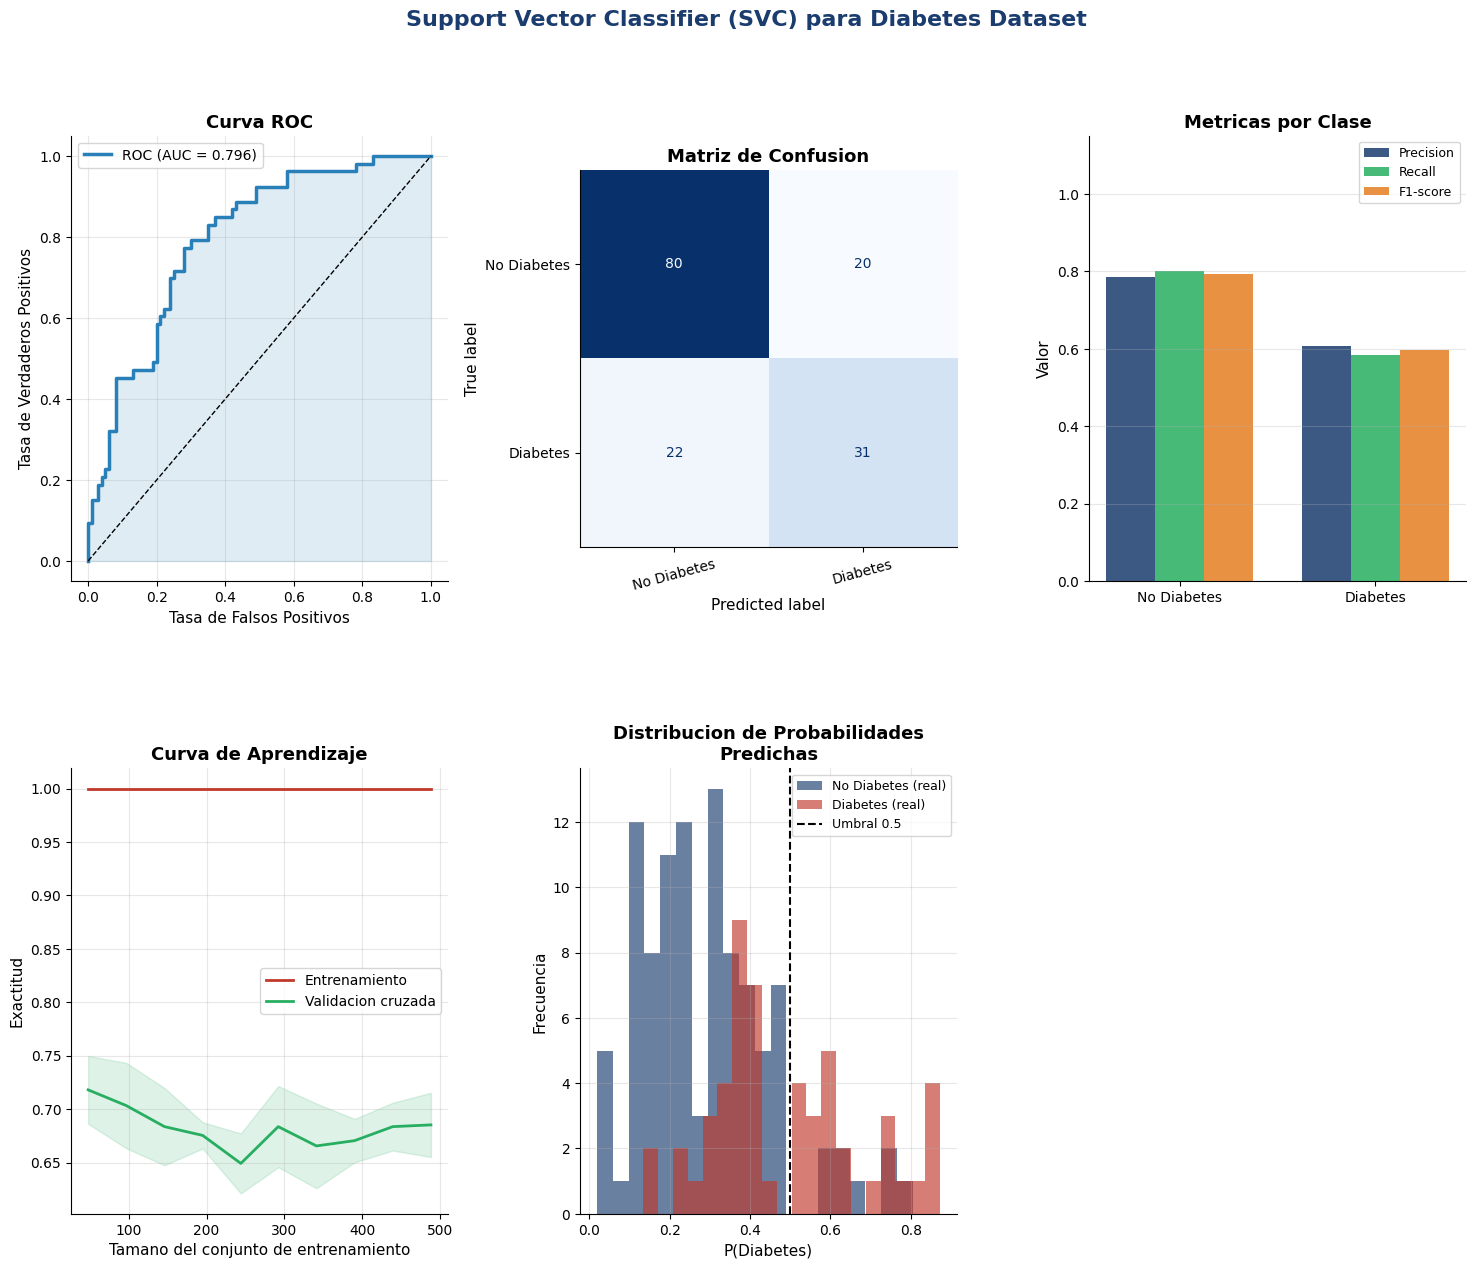

In [5]:
plt.rcParams.update({'font.family': 'DejaVu Sans','axes.spines.top': False,'axes.spines.right': False, 'axes.labelsize': 11, 'axes.titlesize': 13, 'figure.facecolor': 'white'})

ra = 12

# Variable objetivo que contiene la clasificacion
TARGET = 'Resultado'

# Se seleccionan todas las columnas excepto la variable objetivo
features = [c for c in df.columns if c != TARGET]

# Matriz de caracteristicas
X = df[features].values

# Vector de etiquetas
y = df[TARGET].values

# Division del dataset en entrenamiento y prueba
# test_size=0.20 -> 20% para pruebas
# stratify=y -> mantiene la proporcion de clases
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=ra, stratify=y)

# Escalado de datos
# SVM es sensible a diferencias de escala entre variables,
# por ello se utiliza StandardScaler para normalizar

scaler = StandardScaler()

# Ajusta y transforma los datos de entrenamiento
X_train_sc = scaler.fit_transform(X_train)

# Solo transforma los datos de prueba
X_test_sc = scaler.transform(X_test)

# Entrenamiento del modelo SVC

# Se crea un clasificador SVC con:
# kernel='rbf'  -> separacion no lineal
# C=1e6         -> penalizacion muy alta al error
# gamma='scale' -> ajuste automatico del kernel
# probability=True -> habilita probabilidades

svc = SVC(kernel='rbf', C=1e6, gamma='scale', probability=True, random_state=ra)

# Entrenamiento del modelo
svc.fit(X_train_sc, y_train)

# Predicciones y evaluacion

# Predicciones binarias
y_pred_svc = svc.predict(X_test_sc)

# Probabilidad estimada de pertenecer a la clase positiva
y_prob_svc = svc.predict_proba(X_test_sc)[:, 1]

# Accuracy manual
acc_svc = np.mean(y_pred_svc == y_test)

# Matriz de confusion
cm_svc = confusion_matrix(y_test, y_pred_svc)

# Reporte completo de metricas
report_svc = classification_report(y_test, y_pred_svc, target_names=['No Diabetes', 'Diabetes'], output_dict=True)

# Calculo de curva ROC
fpr_svc, tpr_svc, _ = roc_curve(y_test, y_prob_svc)

# Area bajo la curva ROC
auc_svc = auc(fpr_svc, tpr_svc)

# Impresion de resultados

# Paleta de colores utilizada en las graficas
BLUE   = "#1a3c6e"
RED    = "#c0392b"
GRAY   = "#ecf0f1"
ACCENT = "#2980b9"
GREEN  = "#27ae60"
ORANGE = "#e67e22"

print(f"\nSVC con Accuracy: {acc_svc:.4f} y AUC: {auc_svc:.4f}")

# Numero de vectores de soporte por clase
print(f"Vectores de soporte: {svc.n_support_} (No Diab. / Diab.)")

# Total de vectores de soporte
print(f"Total vectores de soporte: {sum(svc.n_support_)}")

print("\nReporte de clasificacion:")

# Muestra precision, recall y F1-score
print(classification_report(y_test, y_pred_svc, target_names=['No Diabetes', 'Diabetes']))

# Creacion de figura general

fig = plt.figure(figsize=(18, 14))
fig.patch.set_facecolor('white')

# Se crea una cuadricula de 2 filas x 3 columnas
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.35)

# Titulo general de la figura
fig.text(0.5, 0.97, "Support Vector Classifier (SVC) para Diabetes Dataset", ha='center', va='top', fontsize=16, fontweight='bold',color=BLUE)

# Curva ROC

ax = fig.add_subplot(gs[0, 0])

# Curva ROC
ax.plot(fpr_svc, tpr_svc, color=ACCENT, lw=2.5, label=f'ROC (AUC = {auc_svc:.3f})')

# Linea diagonal de referencia
ax.plot([0, 1], [0, 1], 'k--', lw=1)

# Area sombreada bajo la curva
ax.fill_between(fpr_svc, tpr_svc, alpha=0.15, color=ACCENT)

ax.set_title("Curva ROC", fontweight='bold')
ax.set_xlabel("Tasa de Falsos Positivos")
ax.set_ylabel("Tasa de Verdaderos Positivos")

ax.legend()
ax.grid(alpha=0.3)

# Matriz de confusion

ax = fig.add_subplot(gs[0, 1])

# Visualizacion de matriz de confusion
disp = ConfusionMatrixDisplay(cm_svc, display_labels=['No Diabetes', 'Diabetes'])

disp.plot(ax=ax, colorbar=False, im_kw={'cmap': plt.cm.Blues})

ax.set_title("Matriz de Confusion", fontweight='bold')

# Rotacion de etiquetas
ax.tick_params(axis='x', labelrotation=15)

# Grafica de metricas por clase

ax = fig.add_subplot(gs[0, 2])

# Clases
classes = ['No Diabetes', 'Diabetes']

# Metricas a comparar
metrics_names = ['precision', 'recall', 'f1-score']
metrics_labels = ['Precision', 'Recall', 'F1-score']

# Posiciones en eje X
x = np.arange(len(classes))

# Ancho de barras
w = 0.25

# Colores para cada metrica
colors_bar = [BLUE, GREEN, ORANGE]

# Construccion de barras
for i, (m, lbl) in enumerate(zip(metrics_names, metrics_labels)):

    # Obtiene los valores de cada metrica
    vals = [report_svc[c][m] for c in classes]

    # Grafica las barras
    ax.bar(x + i * w, vals, w, label=lbl, color=colors_bar[i], alpha=0.85)

ax.set_xticks(x + w)
ax.set_xticklabels(classes)

ax.set_ylim(0, 1.15)

ax.set_ylabel("Valor")

ax.set_title("Metricas por Clase", fontweight='bold')

ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)

# Curva de aprendizaje

ax = fig.add_subplot(gs[1, 0])

# Calcula desempeno del modelo con diferentes tamanos
# de entrenamiento para detectar overfitting

train_sizes, train_scores, test_scores = learning_curve(SVC(kernel='rbf', C=1e6, gamma='scale', probability=True, random_state=ra), X_train_sc, y_train, cv=5, scoring='accuracy', train_sizes=np.linspace(0.1, 1.0, 10), n_jobs=-1)

# Promedios
train_mean = train_scores.mean(axis=1)
test_mean  = test_scores.mean(axis=1)

# Desviaciones estandar
train_std  = train_scores.std(axis=1)
test_std   = test_scores.std(axis=1)

# Curva de entrenamiento
ax.plot(train_sizes, train_mean, color=RED, lw=2,label='Entrenamiento')

# Curva de validacion
ax.plot(train_sizes, test_mean, color=GREEN, lw=2, label='Validacion cruzada')

# Area de incertidumbre entrenamiento
ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15,color=RED)

# Area de incertidumbre validacion
ax.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.15,color=GREEN)

ax.set_title("Curva de Aprendizaje", fontweight='bold')

ax.set_xlabel("Tamano del conjunto de entrenamiento")
ax.set_ylabel("Exactitud")

ax.legend()
ax.grid(alpha=0.3)

# Distribucion de probabilidades
ax = fig.add_subplot(gs[1, 1])

# Probabilidades reales clase negativa
prob_neg = y_prob_svc[y_test == 0]

# Probabilidades reales clase positiva
prob_pos = y_prob_svc[y_test == 1]

# Histograma clase negativa
ax.hist(prob_neg, bins=20, color=BLUE, alpha=0.65, label='No Diabetes (real)')

# Histograma clase positiva
ax.hist(prob_pos, bins=20, color=RED, alpha=0.65, label='Diabetes (real)')

# Umbral de decision
ax.axvline(0.5, color='black', linestyle='--', lw=1.5, label='Umbral 0.5')

ax.set_title("Distribucion de Probabilidades\nPredichas", fontweight='bold')

ax.set_xlabel("P(Diabetes)")
ax.set_ylabel("Frecuencia")

ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# Panel final vacio para texto o resumen

ax = fig.add_subplot(gs[1, 2])

# Se ocultan los ejes para utilizar el espacio como resumen
ax.axis('off')

# Mostrar todas las graficas
plt.show()